<a href="https://colab.research.google.com/github/Maryam-Skaik/cirrhosis-outcome-prediction/blob/main/notebook/cirrhosis-prediction-classification-project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cirrhosis Prediction Classification Project

## Objective
The goal of this project is to build a machine learning classification model capable of predicting patient cirrhosis outcomes using clinical and laboratory data.

This project includes:
- Data cleaning
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Classification modeling
- Feature importance analysis
- Explanatory visualizations

## Dataset Understanding

### What is the target?
The target variable represents the patient outcome/status related to cirrhosis progression.

This is a classification problem because the model predicts categorical outcomes.

### What does one row represent?
Each row represents one patient along with their medical and laboratory measurements.

### Number of features
The dataset contains both numerical and categorical clinical features including laboratory test results, demographic information, and treatment-related variables.

### Opportunities for feature selection
Several medical measurements may contain overlapping information, creating opportunities for feature selection and importance analysis.

### Expected challenges
Potential challenges include:
- Missing values
- Class imbalance
- Mixed data types
- Medical feature interpretation

## Imports

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay, recall_score, precision_score, accuracy_score

from sklearn.inspection import permutation_importance

## Custom Functions

In [ ]:
def classification_metrics(
    y_true, y_pred,
    label='',
    output_dict=False,
    figsize=(8,4),
    normalize='true',
    cmap='Blues',
    colorbar=False
):

    labels = ['C', 'CL', 'D']  # fixed order for 3-class target

    # Classification report with fixed labels
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=labels,
        zero_division=0
    )

    header = "-"*70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    # Raw confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=labels,
        normalize=None,
        cmap='gist_gray',
        colorbar=colorbar,
        ax=axes[0]
    )
    axes[0].set_title("Raw Counts")

    # Normalized confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=labels,
        normalize=normalize,
        cmap=cmap,
        colorbar=colorbar,
        ax=axes[1]
    )
    axes[1].set_title("Normalized Confusion Matrix")

    fig.tight_layout()
    plt.show()

    if output_dict == True:
        return classification_report(
            y_true,
            y_pred,
            labels=labels,
            target_names=labels,
            output_dict=True,
            zero_division=0
        )

In [ ]:
def evaluate_classification(
    model,
    X_train, y_train,
    X_test, y_test,
    figsize=(6,4),
    normalize='true',
    output_dict=False,
    cmap_train='Blues',
    cmap_test="Reds",
    colorbar=False
):

    # Train predictions
    y_train_pred = model.predict(X_train)

    results_train = classification_metrics(
        y_train, y_train_pred,
        output_dict=True,
        figsize=figsize,
        colorbar=colorbar,
        cmap=cmap_train,
        label='Training Data'
    )

    print()

    # Test predictions
    y_test_pred = model.predict(X_test)

    results_test = classification_metrics(
        y_test, y_test_pred,
        output_dict=True,
        figsize=figsize,
        colorbar=colorbar,
        cmap=cmap_test,
        label='Test Data'
    )

    if output_dict == True:
        return {'train': results_train, 'test': results_test}

## Load Dataset

In [ ]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/03-MachineLearning/Week9/Data/cirrhosis.csv'
df = pd.read_csv(fpath)
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


* Dataset is related to liver cirrhosis prediction and patient condition analysis using medical records and laboratory test results

* Dataset contains 20 columns including patient information, clinical observations, blood test results, and disease stage

* Target variable is `Status`, which represents the patient outcome:

  * `C` = Censored (patient alive)
  * `CL` = Liver transplant
  * `D` = Death due to liver disease

* Another important medical severity indicator is `Stage`, which represents the progression stage of cirrhosis from Stage 1 to Stage 4

* `ID` is a unique patient identifier, numerical but not useful for prediction because it does not contain medical meaning

* `N_Days` is numeric and represents survival days after registration; medically, lower values may indicate severe disease and higher mortality risk

* `Status` is the target variable and is nominal categorical because it represents patient condition categories without order

* `Drug` is nominal categorical and represents treatment type (`D-penicillamine` or `Placebo`); medically, treatment may affect survival and disease progression

* `Age` is numeric and measured in days; older patients are medically expected to have higher complications and worse liver condition

* `Sex` is nominal categorical (`M` or `F`); biologically, liver disease progression may differ between males and females

* `Ascites` is nominal categorical (`Y` or `N`) and indicates abdominal fluid accumulation; medically, presence of ascites strongly suggests advanced liver disease

* `Hepatomegaly` is nominal categorical and indicates enlarged liver; medically associated with liver inflammation and cirrhosis severity

* `Spiders` is nominal categorical and represents spider angiomas on skin; medically linked to chronic liver dysfunction

* `Edema` is ordinal categorical (`N`, `S`, `Y`) representing swelling severity; medically, stronger edema usually indicates worse liver function

* `Bilirubin` is numeric and measures bilirubin level in blood; high bilirubin indicates poor liver function and jaundice, making it an important predictive feature

* `Cholesterol` is numeric and represents cholesterol level; abnormal liver function can affect cholesterol metabolism

* `Albumin` is numeric and measures blood protein produced by liver; low albumin medically indicates liver damage and poor prognosis

* `Copper` is numeric and measures copper concentration; elevated copper levels are associated with liver dysfunction

* `Alk_Phos` is numeric and represents alkaline phosphatase enzyme level; high values may indicate bile duct or liver damage

* `SGOT` is numeric and represents liver enzyme level; elevated values suggest liver cell injury or inflammation

* `Tryglicerides` is numeric and measures triglyceride level; abnormal levels may reflect metabolic or liver abnormalities

* `Platelets` is numeric and measures platelet count; low platelet count is commonly associated with advanced cirrhosis and portal hypertension

* `Prothrombin` is numeric and measures blood clotting time; prolonged clotting time medically indicates impaired liver synthetic function

* `Stage` is ordinal categorical because stages have a natural order from mild to severe cirrhosis; higher stage strongly indicates worse disease progression and mortality risk

## Data Understanding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

* Dataset contains 418 rows and 20 columns, which is a moderate dataset size suitable for medical machine learning experiments
* Data types include 10 float features, 3 integer features, and 7 object (categorical) features
* Numerical features mainly represent laboratory test results and medical measurements, while object features represent patient categories and clinical conditions
* Several columns contain missing values, especially medical test and clinical observation features, which means preprocessing and imputation will be required before training models
* `Drug`, `Ascites`, `Hepatomegaly`, `Spiders`, `Cholesterol`, `Copper`, `Alk_Phos`, `SGOT`, and `Tryglicerides` contain a large number of missing values
* `Platelets`, `Prothrombin`, and `Stage` contain only a few missing values, making them easier to handle during preprocessing
* `Status`, `Drug`, `Sex`, `Ascites`, `Hepatomegaly`, `Spiders`, and `Edema` are currently stored as object type and will require encoding before machine learning
* `ID` is numerical but acts only as an identifier and is not expected to contribute to prediction performance

In [ ]:
df = df.drop(columns='ID')
df.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [ ]:
df.describe().round()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.0,418.0,418.0,284.0,418.0,310.0,312.0,312.0,282.0,407.0,416.0,412.0
mean,1918.0,18533.0,3.0,370.0,3.0,98.0,1983.0,123.0,125.0,257.0,11.0,3.0
std,1105.0,3816.0,4.0,232.0,0.0,86.0,2140.0,57.0,65.0,98.0,1.0,1.0
min,41.0,9598.0,0.0,120.0,2.0,4.0,289.0,26.0,33.0,62.0,9.0,1.0
25%,1093.0,15644.0,1.0,250.0,3.0,41.0,872.0,81.0,84.0,188.0,10.0,2.0
50%,1730.0,18628.0,1.0,310.0,4.0,73.0,1259.0,115.0,108.0,251.0,11.0,3.0
75%,2614.0,21272.0,3.0,400.0,4.0,123.0,1980.0,152.0,151.0,318.0,11.0,4.0
max,4795.0,28650.0,28.0,1775.0,5.0,588.0,13862.0,457.0,598.0,721.0,18.0,4.0


* `Bilirubin` ranges from 0–28, with a median of 1 and max far above the 75th percentile (3), indicating strong right skew and possible severe liver cases

* `Cholesterol` ranges from 120–1775, with very high maximum values compared to the median (310), suggesting potential outliers and extreme patient conditions

* `Copper` ranges from 4–588, while the median is only 73, indicating high variability and possible abnormal liver dysfunction cases

* `Alk_Phos` shows extreme spread, ranging from 289–13862 with a very large standard deviation (2140), making it highly skewed and likely containing outliers

* `SGOT` ranges from 26–457 and has noticeable variability, which may reflect different levels of liver inflammation severity

* `Tryglicerides` ranges from 33–598, with several high values compared to the median (108), indicating skewness and possible metabolic abnormalities

* `Platelets` ranges from 62–721, showing wide variation between patients; low platelet values are medically associated with advanced cirrhosis

* `Prothrombin` ranges from 9–18, with most values concentrated around 10–11, meaning the feature has relatively low variability

* `Stage` ranges from 1–4, confirming that cirrhosis severity is categorized into four ordered stages

* `Age` ranges from 9598–28650 days, meaning patients belong to different age groups and age may influence disease progression

* `N_Days` ranges from 41–4795, showing large differences in patient survival duration and disease outcomes

* **Summary:** Several laboratory features such as `Bilirubin`, `Cholesterol`, `Copper`, `Alk_Phos`, and `Tryglicerides` appear heavily right-skewed with potential outliers.

## Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

- Dataset doesn't contain any duplicated record

## Missing Values Check

In [ ]:
df.isna().sum()

,0
N_Days,0
Status,0
Drug,106
Age,0
Sex,0
Ascites,106
Hepatomegaly,106
Spiders,106
Edema,0
Bilirubin,0


In [ ]:
(df.isnull().sum() / len(df) * 100).round(2)

,0
N_Days,0.00
Status,0.00
Drug,25.36
Age,0.00
Sex,0.00
Ascites,25.36
Hepatomegaly,25.36
Spiders,25.36
Edema,0.00
Bilirubin,0.00


* As observed from missing value analysis, several features contain significant missing data, especially `Cholesterol` (32.06%) and `Tryglicerides` (~32.54%), which are the most affected columns

* A group of clinical observation features (`Drug`, `Ascites`, `Hepatomegaly`, `Spiders`, `Alk_Phos`, `SGOT`, `Copper`) each contain around ~25% missing values, indicating systematic missingness across multiple medical tests

* `Platelets`, `Prothrombin`, and `Stage` have very low missing rates (below 3%), meaning they are mostly complete and reliable

* Core survival-related features (`N_Days`, `Status`, `Age`, `Sex`, `Edema`, `Bilirubin`, `Albumin`) have no missing values, which is important for model stability

* Missing values are mainly concentrated in laboratory and diagnostic test features, which is common in real medical datasets where not all tests are performed for every patient

* Imputation will be required before modeling, likely using median for numerical features and mode for categorical features due to skewness and outliers in medical measurements

## Inconsistencies

In [ ]:
for col in df.select_dtypes("object").columns:
    print(col, df[col].value_counts())

Status Status
C     232
D     161
CL     25
Name: count, dtype: int64
Drug Drug
D-penicillamine    158
Placebo            154
Name: count, dtype: int64
Sex Sex
F    374
M     44
Name: count, dtype: int64
Ascites Ascites
N    288
Y     24
Name: count, dtype: int64
Hepatomegaly Hepatomegaly
Y    160
N    152
Name: count, dtype: int64
Spiders Spiders
N    222
Y     90
Name: count, dtype: int64
Edema Edema
N    354
S     44
Y     20
Name: count, dtype: int64


- All values are consistent with dictionary, no need to handle them.

## Exploratory Data Analysis (EDA)

### Target Distribution

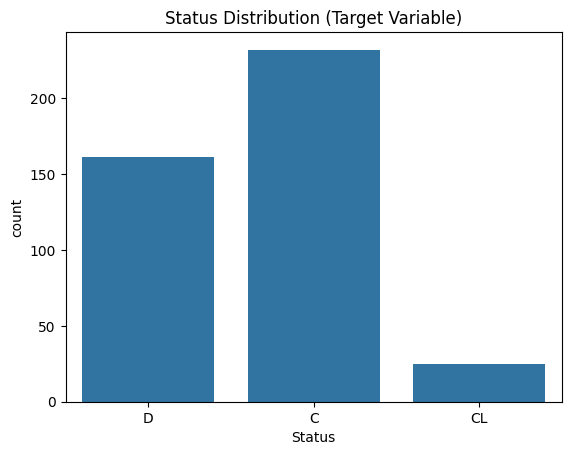

In [ ]:
sns.countplot(x="Status", data=df)
plt.title("Status Distribution (Target Variable)")
plt.show()

In [ ]:
df["Status"].value_counts(normalize=True)

,proportion
Status,
C,0.555024
D,0.385167
CL,0.059809


- The dataset shows multiple outcome classes (C, D, CL), with C (censored/alive) typically being the dominant class

- This indicates a moderate class imbalance, which should be considered during model training

### Stage Distribution (Disease Severity)

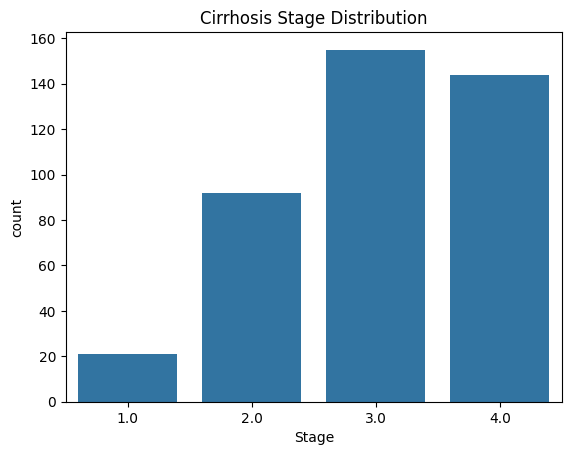

,proportion
Stage,
3.0,0.376214
4.0,0.349515
2.0,0.223301
1.0,0.050971


In [ ]:
sns.countplot(x="Stage", data=df)
plt.title("Cirrhosis Stage Distribution")
plt.show()

df["Stage"].value_counts(normalize=True)

- Most patients are concentrated in Stage 3 and Stage 4, indicating that the dataset is biased toward advanced liver disease cases

- Early stages (1–2) are less represented, which may affect model generalization for early detection

### Correlation Matrix

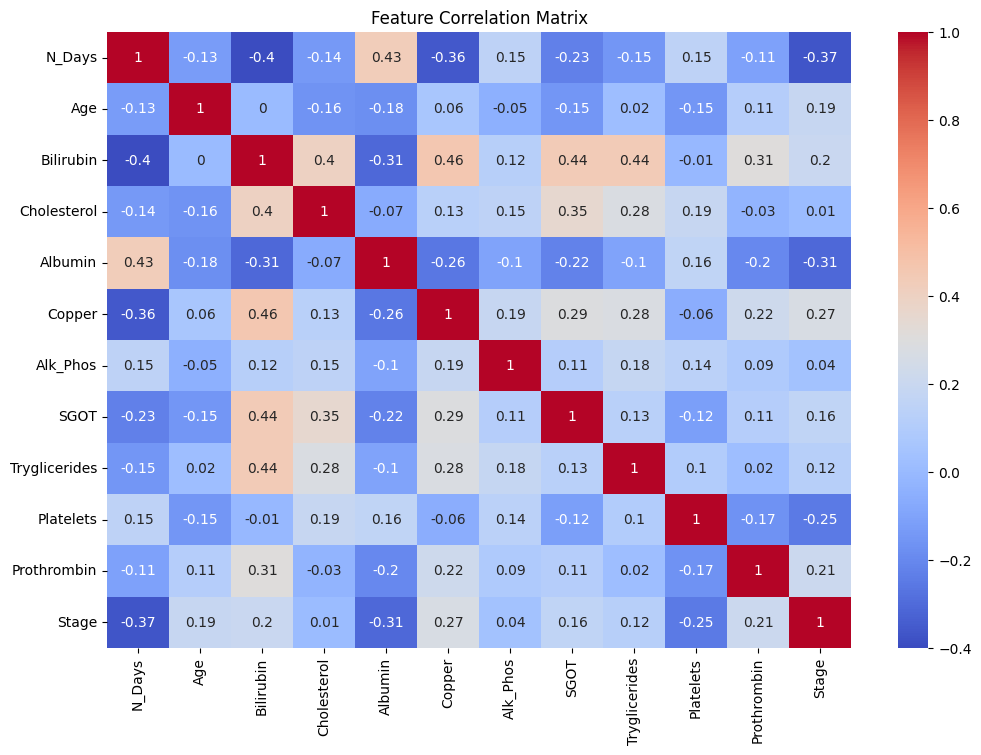

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True).round(2), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

- Strong relationships between liver function markers such as `Bilirubin`, `Alk_Phos`, and `SGOT`

- `Albumin` is negatively correlated with severity indicators like `Stage` and `Bilirubin`

- `Platelets` show inverse correlation with disease severity due to portal hypertension effects

### Distribution of Key Numerical Features

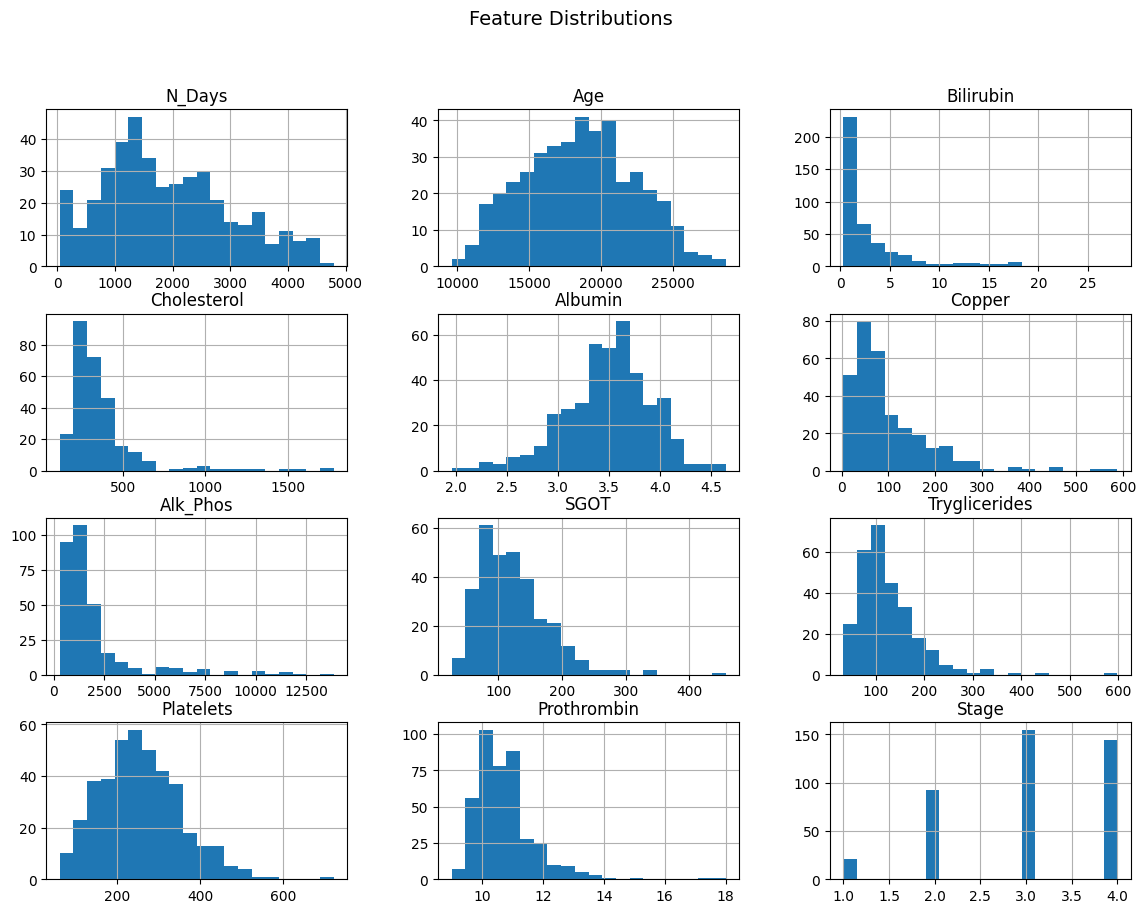

In [ ]:
df.hist(figsize=(14,10), bins=20)
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()

- Most biochemical markers (`Bilirubin`, `Copper`, `Alk_Phos`, `Tryglicerides`) are right-skewed

- `Albumin` is relatively more normally distributed compared to other lab values

- `Platelets` and `Prothrombin` show moderate spread, reflecting variability in clotting and blood function

- Strong skewness in multiple features suggests that log transformation or robust scaling may improve model performance

### Status vs Bilirubin

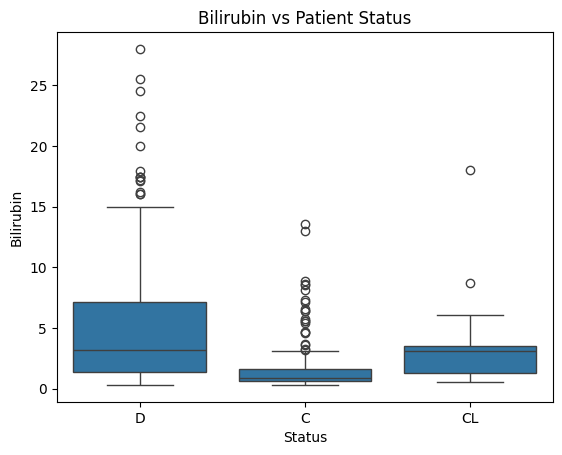

In [ ]:
sns.boxplot(x="Status", y="Bilirubin", data=df)
plt.title("Bilirubin vs Patient Status")
plt.show()

- Patients with outcome D (death) tend to show higher bilirubin levels, indicating severe liver dysfunction

- CL (transplant) cases also show elevated biomarker levels compared to censored patients

- This confirms that bilirubin is a strong predictive feature for liver disease severity

## Feature Setup

In [ ]:
y = df['Status']
X = df.drop(columns='Status')

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## Preprocessing

In [ ]:
num_cols = X_train.select_dtypes('number').columns

impute_num = SimpleImputer(strategy='median')
scaler = StandardScaler()

num_pipe = make_pipeline(impute_num, scaler)

num_tuple = ('num', num_pipe, num_cols)
num_tuple

('num',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                 ('standardscaler', StandardScaler())]),
 Index(['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
        'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
        'Stage'],
       dtype='object'))

In [ ]:
ord_cols = ['Edema']

edema_order = ['N', 'S', 'Y']  # No edema → mild → severe

ordinal_category_orders = [edema_order]

impute_ord = SimpleImputer(strategy='most_frequent')
ord_encoder = OrdinalEncoder(categories=ordinal_category_orders)
scaler = StandardScaler()

ord_pipe = make_pipeline(impute_ord, ord_encoder, scaler)

ord_tuple = ('ord', ord_pipe, ord_cols)
ord_tuple

('ord',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                 ('ordinalencoder',
                  OrdinalEncoder(categories=[['N', 'S', 'Y']])),
                 ('standardscaler', StandardScaler())]),
 ['Edema'])

In [ ]:
cat_cols = ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders']

impute_cat = SimpleImputer(strategy='most_frequent')

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

cat_pipe = make_pipeline(impute_cat, ohe)

cat_tuple = ('cat', cat_pipe, cat_cols)
cat_tuple

('cat',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                 ('onehotencoder',
                  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
 ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders'])

In [ ]:
preprocessor = ColumnTransformer([num_tuple, ord_tuple, cat_tuple], verbose_feature_names_out=False)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
       'Stage'],
      dtype='object')),
                                ('ord',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer...
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(categories=[['N',
                                                                              'S',
                                                                              'Y']])),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['Edema']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Drug', 'Sex', 'Ascites', 'Hepatomegaly',
                                  'Spiders'])],
                  verbose_feature_names_out=False)

## Model Pipeline

### Random Forest

In [ ]:
rf = RandomForestClassifier()
rf_pipe = make_pipeline(preprocessor, rf)
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
       'Stage'],
      dtype='object')),
                                                 ('ord',
                                                  Pipeline(...
                                                                                               'Y']])),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Edema']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Drug', 'Sex', 'Ascites',
                                                   'Hepatomegaly',
                                                   'Spiders'])],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier', RandomForestClassifier())])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           C       1.00      1.00      1.00       177
          CL       1.00      1.00      1.00        19
           D       1.00      1.00      1.00       117

    accuracy                           1.00       313
   macro avg       1.00      1.00      1.00       313
weighted avg       1.00      1.00      1.00       313



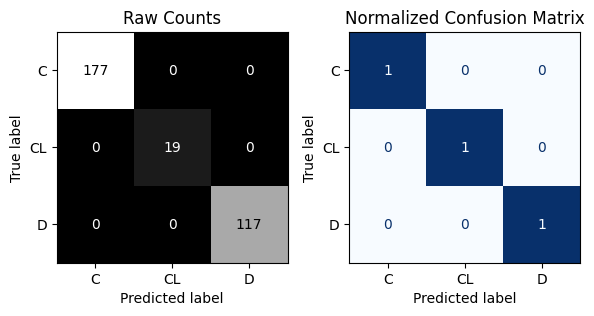


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           C       0.74      0.89      0.81        55
          CL       0.00      0.00      0.00         6
           D       0.79      0.70      0.75        44

    accuracy                           0.76       105
   macro avg       0.51      0.53      0.52       105
weighted avg       0.72      0.76      0.74       105



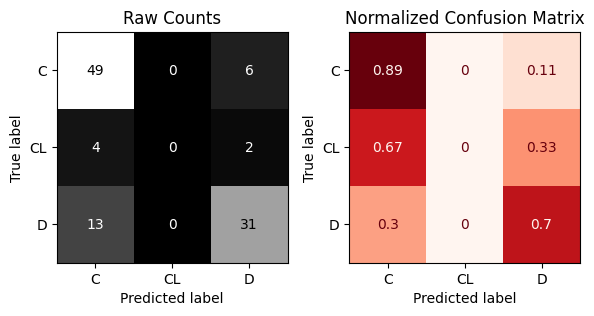

In [ ]:
evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test)

* Training results show **perfect performance (accuracy = 1.00)** across all classes (`C`, `CL`, `D`), with precision, recall, and F1-score all equal to 1.00

* This indicates the model is likely **overfitting the training data**, learning it too well instead of general patterns

* Test results show a **significant performance drop (accuracy = 0.74)**, confirming overfitting behavior

* Class `C` performs relatively well on test data (F1 ≈ 0.79), meaning the model can identify censored/alive patients fairly well

* Class `D` (death) shows moderate performance (F1 ≈ 0.74), indicating reasonable but imperfect detection of severe cases

* Class `CL` (transplant) has **zero precision, recall, and F1-score**, meaning the model completely fails to learn this class due to its very small representation in the dataset

* Macro average is very low (~0.51), showing that performance is **not balanced across classes**

* Weighted average (0.72 F1) is higher than macro average, confirming that results are dominated by majority classes (`C` and `D`)

* Overall conclusion: dataset is imbalanced, and model overfits training data while failing on minority class → requires **resampling (SMOTE / class weights) or better regularization**

In [ ]:
rf_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='median')),
                                                    ('standardscaler',
                                                     StandardScaler())]),
                                    Index(['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
          'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
          'Stage'],
         dtype='object')),
                                   ('ord',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer...
                                                    ('ordinalencoder',
                                                     OrdinalEncoder(categories=[['N',
                                 

In [ ]:
param_grid = {
    'randomforestclassifier__n_estimators': [100, 200, 400],
    'randomforestclassifier__max_depth': [None, 5, 10, 20],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4],
    'randomforestclassifier__max_features': ['sqrt', 'log2'],
    'randomforestclassifier__class_weight': [None, 'balanced']
}

In [ ]:
rf_gs = GridSearchCV(rf_pipe, param_grid, cv=3, verbose=1, n_jobs=-1, scoring='f1_macro')
rf_gs.fit(X_train, y_train)

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         Index(['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
       'Stage'],
      dtype...
             param_grid={'randomforestclassifier__class_weight': [None,
                                                                  'balanced'],
                         'randomforestclassifier__max_depth': [None, 5, 10, 20],
                         'randomforestclassifier__max_features': ['sqrt',
                                                                  'log2'],
                         'randomforestclassifier__min_samples_leaf': [1, 2, 4],
                         'randomforestclassifier__min_samples_split': [2, 5,
                                                                       10],
                         'randomforestclassifier__n_estimators': [100, 200,
                                                                  400]},
             scoring='f1_macro', verbose=1)

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           C       0.93      0.92      0.92       177
          CL       0.90      1.00      0.95        19
           D       0.88      0.89      0.89       117

    accuracy                           0.91       313
   macro avg       0.91      0.93      0.92       313
weighted avg       0.91      0.91      0.91       313



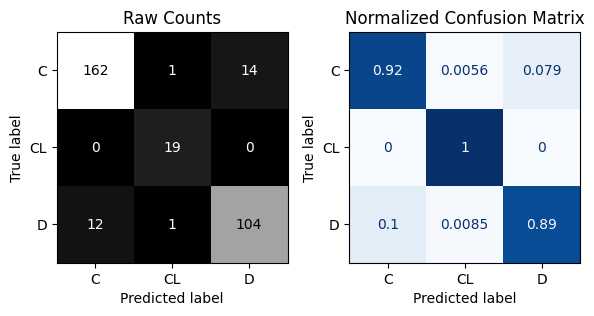


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           C       0.79      0.80      0.79        55
          CL       0.25      0.17      0.20         6
           D       0.76      0.77      0.76        44

    accuracy                           0.75       105
   macro avg       0.60      0.58      0.59       105
weighted avg       0.74      0.75      0.75       105



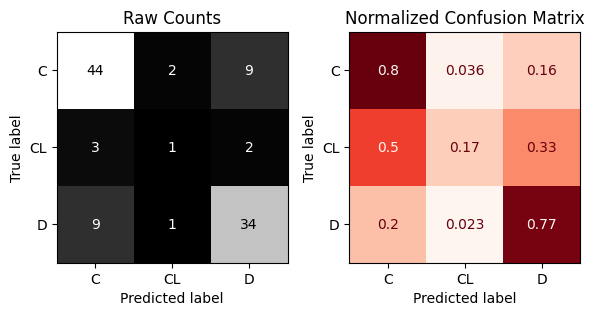

In [ ]:
evaluate_classification(rf_gs.best_estimator_, X_train, y_train, X_test, y_test)

* After hyperparameter tuning, training performance became more realistic with accuracy reduced from 1.00 to **0.91**, indicating reduced overfitting compared to the previous model

* Training metrics are now more balanced across classes (`C`, `CL`, `D`), showing that the model generalizes better on the training set

* Test accuracy is **0.75**, which is consistent with the previous model, but now with a more stable training–test gap

* Class `C` (censored/alive) performs well in test data (F1 ≈ 0.79), meaning the model reliably detects majority cases

* Class `D` (death) also shows strong performance (F1 ≈ 0.76), indicating good predictive ability for severe cases

* Class `CL` (transplant) is still poorly predicted (F1 ≈ 0.20), due to its very small number of samples and class imbalance

* Macro average (F1 ≈ 0.59) is significantly lower than weighted average, confirming that minority class performance is still weak

* Overall improvement: model is now less overfitted and more stable, but **class imbalance problem is still not fully solved**, especially for `CL` class

## SOMTE

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

model = RandomForestClassifier(random_state=42)

pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', model)
])

In [ ]:
param_grid = {
    'classifier__n_estimators': [100, 200, 400],
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__class_weight': [None, 'balanced']
}

In [ ]:
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         Index(['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
       'Stage'],
      dtype='objec...
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__class_weight': [None, 'balanced'],
                         'classifier__max_depth': [None, 5, 10, 20],
                         'classifier__max_features': ['sqrt', 'log2'],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 200, 400]},
             scoring='f1_macro', verbose=2)

In [ ]:
grid.best_params_

{'classifier__class_weight': None,
 'classifier__max_depth': 5,
 'classifier__max_features': 'sqrt',
 'classifier__min_samples_leaf': 2,
 'classifier__min_samples_split': 5,
 'classifier__n_estimators': 100}

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           C       0.89      0.88      0.88       177
          CL       0.55      0.84      0.67        19
           D       0.86      0.81      0.84       117

    accuracy                           0.85       313
   macro avg       0.77      0.84      0.80       313
weighted avg       0.86      0.85      0.85       313



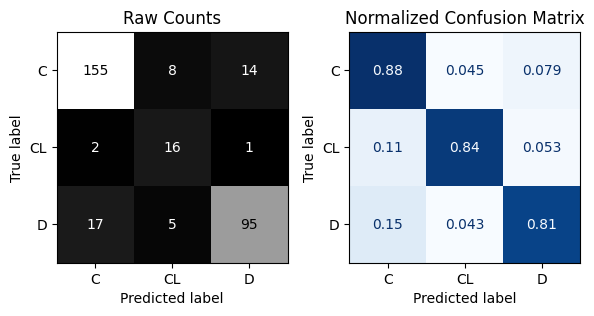


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           C       0.79      0.76      0.78        55
          CL       0.50      0.67      0.57         6
           D       0.77      0.77      0.77        44

    accuracy                           0.76       105
   macro avg       0.69      0.73      0.71       105
weighted avg       0.77      0.76      0.76       105



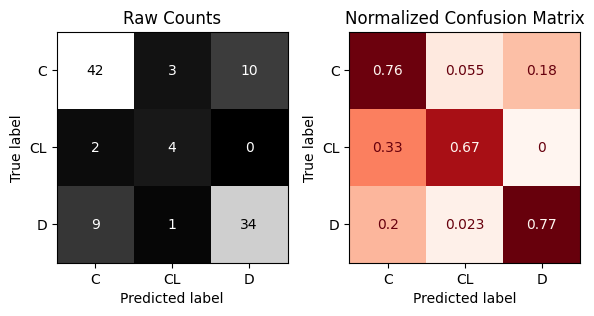

In [ ]:
best_model = grid.best_estimator_

evaluate_classification(
    best_model,
    X_train, y_train,
    X_test, y_test
)

* After applying SMOTE and hyperparameter tuning, the model shows a more balanced learning behavior across all classes

* Training performance decreased to **accuracy = 0.85**, which indicates reduced overfitting and better generalization compared to previous models

* The model now handles the minority class `CL` much better, with a significant improvement in recall (0.84 in training and 0.67 in test)

* Test accuracy is **0.76**, which is stable and consistent with training performance, confirming a good generalization gap

* Class `C` and `D` both maintain strong and balanced performance (F1 ≈ 0.77–0.78), showing reliable prediction for majority medical outcomes

* Class `CL` shows major improvement compared to previous models (F1 increased to 0.57), meaning SMOTE successfully helped the model learn minority patterns

* Macro average (F1 ≈ 0.71) is significantly improved compared to earlier results, indicating better performance across all classes equally

* Weighted average remains close to macro average, showing the model is no longer biased toward majority classes

* Overall conclusion: SMOTE + tuning successfully reduced class imbalance impact and improved minority class detection, especially for transplant cases (`CL`), making the model more suitable for medical decision support

## Permutation Importance

In [ ]:
result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=42
)

importances = pd.Series(result.importances_mean, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)
top10

,0
Bilirubin,0.090476
Age,0.058095
N_Days,0.045714
Prothrombin,0.040952
Drug,0.013333
Platelets,0.013333
Copper,0.008571
SGOT,0.004762
Edema,0.003810
Ascites,0.003810


### Plot Top 10 Features

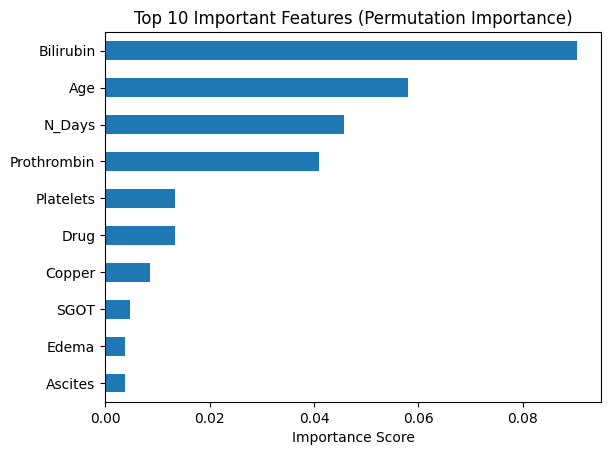

In [37]:
top10.sort_values().plot(kind='barh')
plt.title("Top 10 Important Features (Permutation Importance)")
plt.xlabel("Importance Score")
plt.show()

* `Bilirubin` appears as the most important feature, which strongly makes sense medically because elevated bilirubin is a key indicator of liver dysfunction and cirrhosis severity

* `Age` and `N_Days` are also highly important, indicating that patient age and survival duration have strong relationships with disease outcome and progression

* `Prothrombin` is among the top predictors, which is medically reasonable because impaired blood clotting is a common sign of advanced liver failure

* Features such as `Platelets`, `Copper`, `SGOT`, `Edema`, and `Ascites` are clinically associated with cirrhosis complications, so their importance aligns well with the medical business case

* `Ascites` and `Edema` represent fluid accumulation symptoms commonly observed in severe liver disease, making their contribution medically meaningful

* `Drug` having some importance suggests that treatment type may influence patient outcomes and progression patterns

* Overall, the top features are medically logical and consistent with real cirrhosis severity indicators, showing that the model is learning clinically meaningful patterns rather than random relationships

* The model mainly relies on laboratory liver-function markers and advanced disease symptoms, which matches the healthcare objective of predicting cirrhosis outcomes accurately

### Visualization 1 — Bilirubin vs Patient Outcome

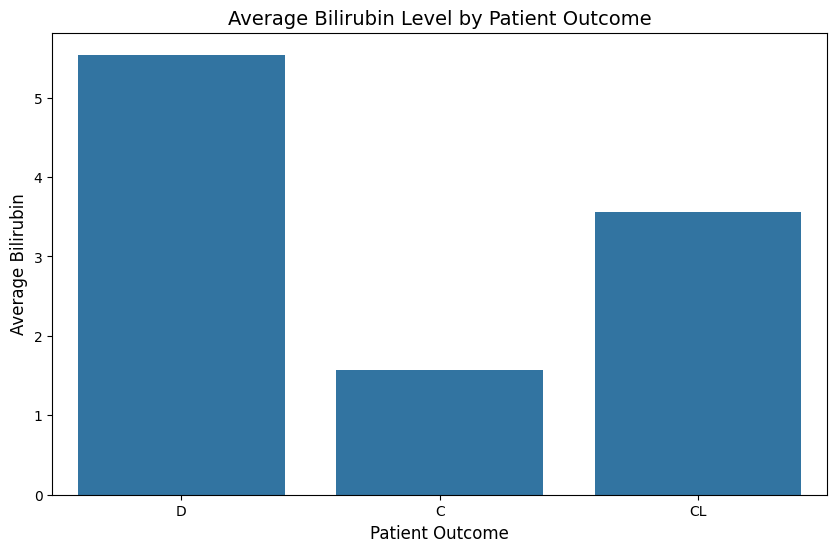

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Status',
    y='Bilirubin',
    estimator='mean',
    errorbar=None
)

plt.title('Average Bilirubin Level by Patient Outcome', fontsize=14)
plt.xlabel('Patient Outcome', fontsize=12)
plt.ylabel('Average Bilirubin', fontsize=12)

plt.show()

- Patients in the `D` (death) group show the highest average bilirubin levels, indicating severe liver dysfunction

- Patients in the `C` group have much lower bilirubin values, suggesting better liver function and survival outcomes

- This trend supports the medical importance of bilirubin as a major indicator of cirrhosis severity and patient prognosis

### Visualization 2 — Prothrombin vs Patient Outcome

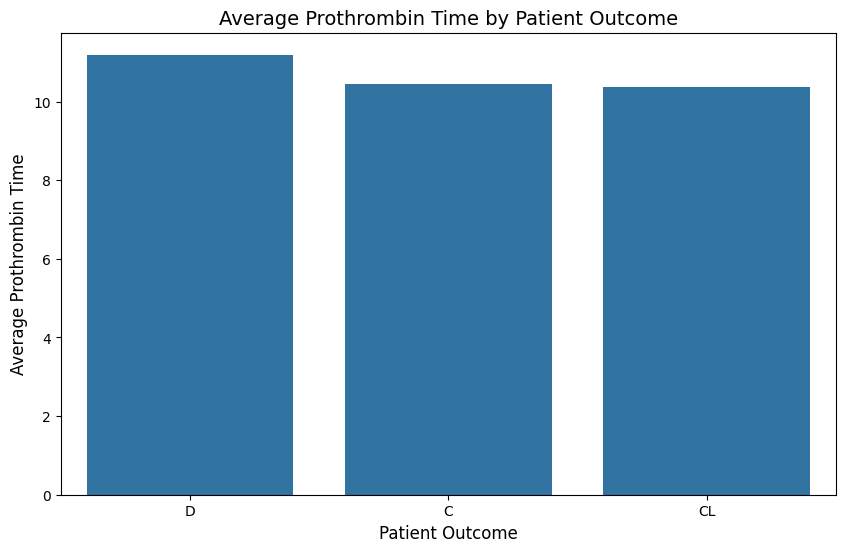

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Status',
    y='Prothrombin',
    estimator='mean',
    errorbar=None
)

plt.title('Average Prothrombin Time by Patient Outcome', fontsize=14)
plt.xlabel('Patient Outcome', fontsize=12)
plt.ylabel('Average Prothrombin Time', fontsize=12)

plt.show()

* Patients with outcome `D` (death) show the highest average Prothrombin Time compared to the other groups

* Outcomes `C` and `CL` have lower and relatively similar average values, indicating better clotting function compared to severe cases

* Higher Prothrombin Time reflects slower blood clotting, which is medically associated with impaired liver function and advanced cirrhosis

* Although the differences between groups are not extremely large, the trend still supports the clinical importance of Prothrombin as a severity indicator

* All averages remain within or close to the general clinical range, suggesting that Prothrombin alone may not fully separate outcomes but still contributes useful predictive information when combined with other biomarkers

* Overall, the visualization demonstrates that worsening patient outcomes tend to be associated with reduced liver clotting functionality, which aligns with the medical business case

## Final Conclusion

* This project analyzed a liver cirrhosis dataset to predict patient outcomes (`C`, `CL`, `D`) using clinical observations, laboratory tests, and disease severity indicators

* Initial data exploration revealed:

  * Significant missing values in several medical test features
  * Strongly skewed laboratory measurements with multiple outliers
  * Class imbalance, especially for the transplant class (`CL`)

* Data preprocessing included:

  * Median imputation for numerical features due to skewness and outliers
  * Most-frequent imputation for categorical variables
  * Encoding of nominal and ordinal categorical features
  * Feature scaling for numerical stability

* Exploratory Data Analysis (EDA) showed that:

  * Advanced cirrhosis stages dominate the dataset
  * Several biomarkers such as `Bilirubin`, `Prothrombin`, `Platelets`, and `Albumin` are strongly related to disease severity and patient outcomes
  * Many numerical medical features are right-skewed, reflecting severe patient cases

* The initial Random Forest model achieved perfect training accuracy but significantly lower test performance, indicating strong overfitting and poor handling of minority classes

* Hyperparameter tuning improved generalization by reducing overfitting, but the model still struggled with the minority transplant class (`CL`) due to dataset imbalance

* Applying SMOTE successfully improved minority class learning:

  * Test accuracy reached approximately 76%
  * Macro F1-score improved significantly
  * Prediction quality for the `CL` class increased substantially compared to earlier models

* Permutation importance analysis identified the most influential features:

  * `Bilirubin`
  * `Age`
  * `N_Days`
  * `Prothrombin`
  * `Platelets`
  * `Copper`

  These features are medically meaningful and align with known cirrhosis severity indicators, confirming that the model learned clinically relevant patterns

* Explanatory visualizations further demonstrated that:

  * Higher bilirubin levels are associated with worse patient outcomes
  * Increased prothrombin time is linked to impaired liver function and more severe disease progression

* Overall, the final model provides a reasonable balance between performance and generalization while improving fairness across patient outcome classes

## Recommendations

* Medical monitoring should focus strongly on liver-function biomarkers such as `Bilirubin`, `Prothrombin`, `Platelets`, and `Copper`, as they showed high predictive importance

* Additional data collection for minority outcome classes, especially transplant cases (`CL`), would likely improve future model performance and reliability